# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters? **Adding a penalty on coefficient size discourages overly complex models and rather pushes the model toward simplicity & stability.**
2. How does regularization provide a way of exploring the bias-variance trade-off? **Regularization lets us tune model complexity continuously (through the above mentioned penalties). Through a very small penalty, the model is flexible and may have low bias but high variance. When the penalty increases, coefficients shrink, variance decreases, but bias increases, showing the trade-off.**
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems? **Ridge usually shrinks coefficients toward zero but rarely makes them exactly zero. LASSO can set some coefficients exactly to zero, so it also performs variable selection. This results in Ridge tending to keep all predictors with smaller weights, while LASSO tending to produce a more sparse model.**
4. How do we typically scale variables for use in regularized regression? Why? **Typically by standardizing predictors (by centering to mean 0) and scaling to std.dev 1. The penalty acts on coefficient magnitudes, so variables measured on larger units would be penalized unfairly less or more, without this scaling/standardization.**
5. How is the penalty $\alpha$ typically selected? **It's typically selected through cross-validation, fitting the model over a grid of alpha values and picking the best performing one.**
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not? **No, because the penalty is used to estimate coefficients, but we instead use the validation metric, as it'll reflect the predictive performance on unseen data.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import KFold

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 


In [3]:
df = pd.read_csv("data/cars_hw.csv")
df["Age"] = 2023 - df["Make_Year"] # took a look at the dataset and it seems to be age since 2023?
X_base = df[["Mileage_Run", "Age"]]
y = df["Price"]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
scaler = StandardScaler()
X = scaler.fit_transform(X_poly)
print(feature_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`? **Negative**


In [5]:
lr = LinearRegression()
lr.fit(X, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)
print("Sign:")
interaction_sign = np.sign(lr_coefs["Mileage_Run Age"])
if interaction_sign > 0: print("Positive")
elif interaction_sign < 0: print("Negative")
else: print("Zero")

Sign:
Negative


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)


In [6]:
alphas = np.logspace(1, 3, 20)
cv = KFold(n_splits=20, shuffle=True, random_state=42)
lasso = LassoCV(alphas=alphas, cv=cv, random_state=42, max_iter=200000)
lasso.fit(X, y)
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
print("alpha from LassoCV:")
print(lasso.alpha_)

alpha from LassoCV:
143.8449888287663


4. Plot the cross-validated MSE by $\alpha$.


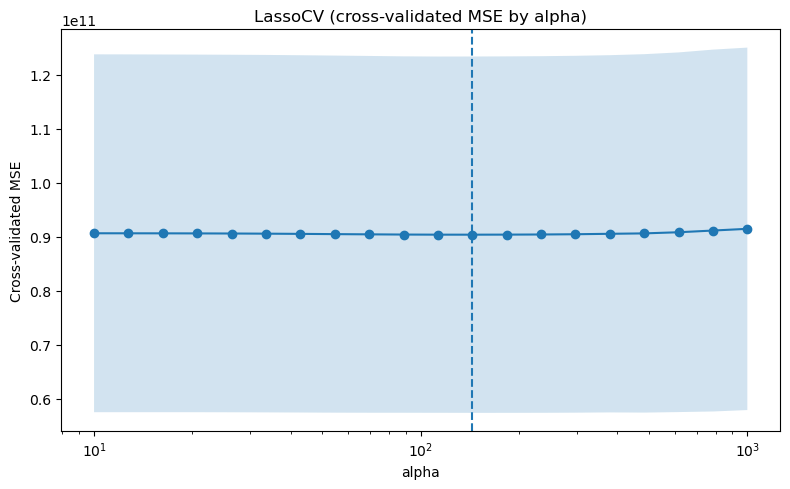

In [9]:
mean_mse = lasso.mse_path_.mean(axis=1)
std_mse = lasso.mse_path_.std(axis=1)
plt.figure(figsize=(8, 5))
plt.semilogx(lasso.alphas_, mean_mse, marker='o')
plt.fill_between(lasso.alphas_, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2)
plt.axvline(lasso.alpha_, linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LassoCV (cross-validated MSE by alpha)")
plt.tight_layout()
plt.show()

5. Plot the coefficient paths by $\alpha$.


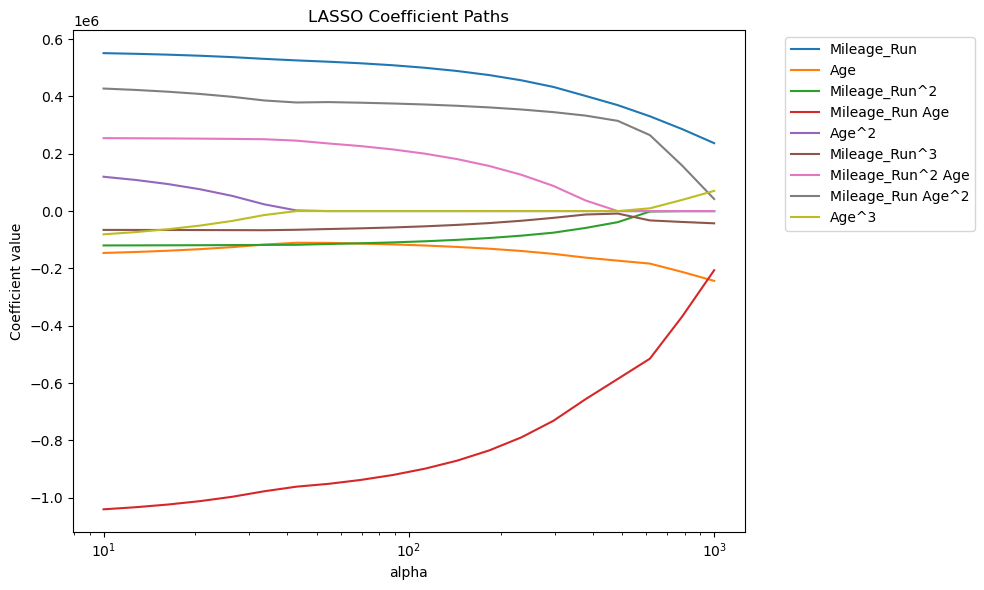

In [10]:
path_alphas, path_coefs, _ = lasso_path(X, y, alphas=alphas, max_iter=200000)
plt.figure(figsize=(10, 6))
for i, name in enumerate(feature_names):
    plt.semilogx(path_alphas, path_coefs[i], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left") # I used ChatGPT to acquire the bbox_to_anchor portion of this line.
plt.tight_layout()
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? **Answers are in the output below.**


In [11]:
selected_features = lasso_coefs[lasso_coefs != 0]
zero_mask = (lasso_coefs == 0)
zero_count = zero_mask.sum()
zero_prop = zero_mask.mean()
print("Actually selected features:")
print(selected_features.index.tolist())
print(f"Proportion set to zero: {zero_prop:.3f}")

Actually selected features:
['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2']
Proportion set to zero: 0.222


7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? **No coefficients increase in magnitude from LinReg to LASSO. Age^2 and Age^3 change sign.**

In [12]:
comparison = pd.DataFrame({"LinearRegression": lr_coefs, "LASSO": lasso_coefs})
comparison["inc_lasso"] = comparison["LASSO"].abs() > comparison["LinearRegression"].abs()
comparison["sign_change"] = np.sign(comparison["LASSO"]) != np.sign(comparison["LinearRegression"])
print("Coefficients increase in magnitude from LinReg to LASSO")
print(comparison["inc_lasso"].any())
print("Features whose sign changed:")
print(comparison.index[comparison["sign_change"]].tolist())

Coefficients increase in magnitude from LinReg to LASSO
False
Features whose sign changed:
['Age^2', 'Age^3']


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.


In [14]:
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
X_cont_raw = df[["age", "ejection_fraction", "serum_creatinine"]]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont_raw)
cont_feature_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
scaler = StandardScaler()
X_cont = scaler.fit_transform(X_cont_poly)
X_cat_raw = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
poly_cat = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)
X_cat = poly_cat.fit_transform(X_cat_raw)
cat_feature_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
X = np.hstack([X_cont, X_cat])
feature_names = np.concatenate([cont_feature_names, cat_feature_names])
y = df["DEATH_EVENT"].values
print(feature_names)

['age' 'ejection_fraction' 'serum_creatinine' 'age^2'
 'age ejection_fraction' 'age serum_creatinine' 'ejection_fraction^2'
 'ejection_fraction serum_creatinine' 'serum_creatinine^2' 'age^3'
 'age^2 ejection_fraction' 'age^2 serum_creatinine'
 'age ejection_fraction^2' 'age ejection_fraction serum_creatinine'
 'age serum_creatinine^2' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine'
 'ejection_fraction serum_creatinine^2' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'smoking' 'anaemia diabetes'
 'anaemia high_blood_pressure' 'anaemia smoking'
 'diabetes high_blood_pressure' 'diabetes smoking'
 'high_blood_pressure smoking' 'anaemia diabetes high_blood_pressure'
 'anaemia diabetes smoking' 'anaemia high_blood_pressure smoking'
 'diabetes high_blood_pressure smoking'
 'anaemia diabetes high_blood_pressure smoking']


2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction? **Some sign patterns that appear counterintuitive are age being positive, while age^2 is negative, and then age^3 is positive. Additionally, serum_creatinine may be negative while higher-order terms alter the total shape. Yes, I can see how these higher-order powers might resolve this said contradiction.**


In [16]:
lr = LinearRegression()
lr.fit(X, y)
ols_coefs = pd.Series(lr.coef_, index=feature_names)
print("\nOLS coefficients")
print(ols_coefs)
print("\nLargest OLS coefficients")
print(ols_coefs.reindex(ols_coefs.abs().sort_values(ascending=False).index).head(15))


OLS coefficients
age                                             1.619432
ejection_fraction                              -2.062277
serum_creatinine                               -0.757092
age^2                                          -3.717758
age ejection_fraction                          -0.800726
age serum_creatinine                            1.707056
ejection_fraction^2                             3.352956
ejection_fraction serum_creatinine              2.569764
serum_creatinine^2                             -2.640240
age^3                                           1.963124
age^2 ejection_fraction                         1.054408
age^2 serum_creatinine                         -0.679042
age ejection_fraction^2                        -0.066433
age ejection_fraction serum_creatinine         -1.626996
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction^2 serum_creatinine           -1.151378
ejection_frac

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)


In [17]:
alphas = np.logspace(-5,5,30)
cv = KFold(n_splits=20, shuffle=True, random_state=42)
lasso = LassoCV(alphas=alphas, cv=cv, random_state=42, max_iter=500000)
lasso.fit(X, y)
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
print("alpha from LassoCV:", lasso.alpha_)

alpha from LassoCV: 0.005736152510448681


4. Plot the cross-validated MSE by $\alpha$.


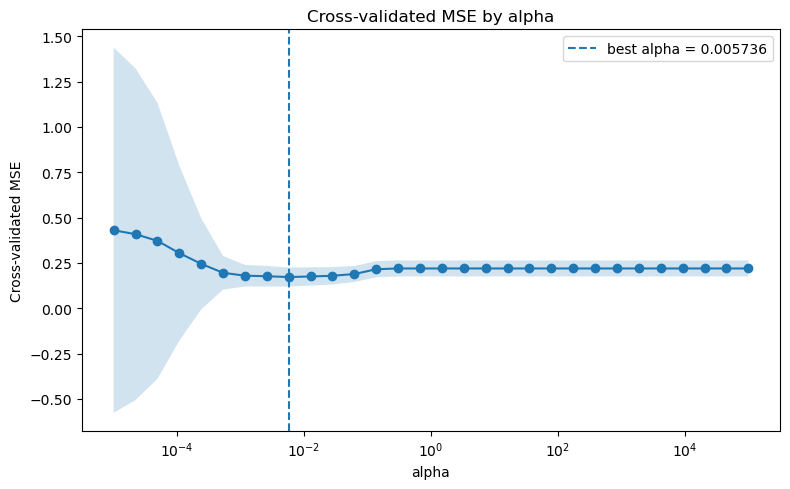

In [18]:
mean_mse = lasso.mse_path_.mean(axis=1)
std_mse = lasso.mse_path_.std(axis=1)
plt.figure(figsize=(8, 5))
plt.semilogx(lasso.alphas_, mean_mse, marker="o")
plt.fill_between(lasso.alphas_, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2)
plt.axvline(lasso.alpha_, linestyle="--", label=f"best alpha = {lasso.alpha_:.6f}")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-validated MSE by alpha")
plt.legend()
plt.tight_layout()
plt.show()

5. Plot the coefficient paths by $\alpha$.


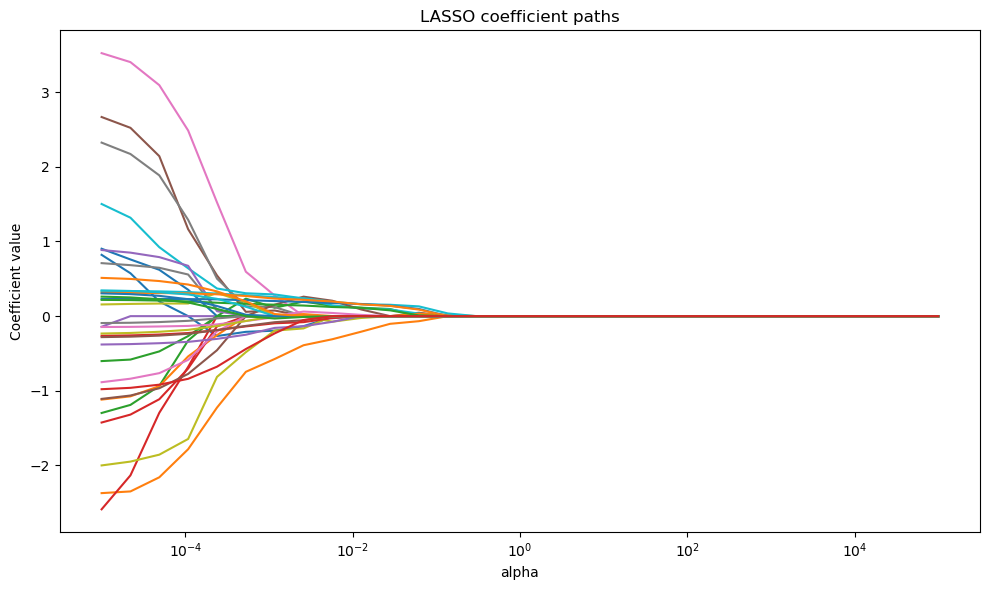

In [19]:
path_alphas, path_coefs, _ = lasso_path(X, y, alphas=alphas, max_iter=500000)
plt.figure(figsize=(10, 6))
for i, name in enumerate(feature_names):
    plt.semilogx(path_alphas, path_coefs[i], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO coefficient paths")
plt.tight_layout()
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off. **Most of the answers to these questions are in the output below. The LASSO sign pattern is more believable, because the ordinary linear model has lower bias but higher variance, so with many correlated higher-order features it can produce erratic coefficient signs. LASSO introduces some bias, but in exchange it lowers variance and allows for a  more stable model. This is essentially the bias-variance trade-off.**

In [21]:
selected = lasso_coefs[lasso_coefs != 0]
zero_mask = (lasso_coefs == 0)
print("Selected features:")
print(selected)
print("Number selected:", (lasso_coefs != 0).sum())
print("Number set to zero:", zero_mask.sum())
print("Proportion set to zero:", zero_mask.mean())

comparison = pd.DataFrame({"OLS": ols_coefs, "LASSO": lasso_coefs})
comparison["inc_lasso"] = comparison["LASSO"].abs() > comparison["OLS"].abs()
comparison["sign_change"] = np.sign(comparison["LASSO"]) != np.sign(comparison["OLS"])
print("Coefficient comparison:")
print(comparison)
print("Any coefficients increase in magnitude from LinReg to LASSO")
print(comparison["inc_lasso"].any())
print("Features with sign changes:")
print(comparison.index[comparison["sign_change"]].tolist())

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Number selected: 12
Number set to zero: 22
Proportion set to zero: 0.6470588235294118
Coefficient comparison:
                                                   OLS     LASSO  inc_lasso  \
age                                           1.619432 -0.000000      False   
ejection_fraction                            -2.062277 -0.329656      False   
serum_creatinine               

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

Since the model is

$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$

the objective function is

$$
\min_{\tilde{b}_0,\tilde{b}_1}
\left[
\frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)^2
\;+\;
\alpha (\tilde{b}_1)^2
\right].
$$

Here, the first term is the mean squared error, and the second term is the ridge penalty on the slope coefficient.

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

Start with the ridge objective function:

$$
\min_{\tilde{b}_0,\tilde{b}_1}
\left[
\frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)^2
\;+\;
\alpha (\tilde{b}_1)^2
\right].
$$

We first take the derivative with respect to $\tilde{b}_0$:

$$
\frac{\partial}{\partial \tilde{b}_0}
\left[
\frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)^2
\right]
=
-\frac{2}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right).
$$

Setting this equal to zero gives us

$$
\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right) = 0.
$$

Expand it out

$$
\sum_{i=1}^n \tilde{y}_i - n\tilde{b}_0 - \tilde{b}_1 \sum_{i=1}^n \tilde{x}_i = 0.
$$

Because the variables are mean-centered, we can set equal to 0.

$$
\sum_{i=1}^n \tilde{y}_i = 0
\quad \text{and} \quad
\sum_{i=1}^n \tilde{x}_i = 0.
$$

So, this ultimately simplifies to

$$
\tilde{b}_0 = 0.
$$

Now for b1, take the derivative with respect to $\tilde{b}_1$:

$$
\frac{\partial}{\partial \tilde{b}_1}
\left[
\frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)^2
+
\alpha (\tilde{b}_1)^2
\right]
=
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)
+
2\alpha \tilde{b}_1.
$$

Substituting $\tilde{b}_0 = 0$ and setting the derivative equal to zero gives

$$
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i \left(\tilde{y}_i - \tilde{b}_1 \tilde{x}_i\right)
+
2\alpha \tilde{b}_1
= 0.
$$

Dividing through by $2$ and rearrange terms

$$
\tilde{b}_1
\left(
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha
\right)
=
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i.
$$

We now have this (after also dividing by $n$)

$$
\tilde{b}_1
=
\frac{
\sum_{i=1}^n \tilde{x}_i \tilde{y}_i
}{
\sum_{i=1}^n \tilde{x}_i^2 + n\alpha
}.
$$

Final answers:

$$
\tilde{b}_0 = 0
\quad \text{and} \quad
\tilde{b}_1
=
\frac{
\sum_{i=1}^n \tilde{x}_i \tilde{y}_i
}{
\sum_{i=1}^n \tilde{x}_i^2 + n\alpha
}.
$$

3. How does increasing $\alpha$ change the slope coefficient?

We can see that increasing $\alpha$ makes the denominator larger. As a result, the slope coefficient is pulled closer to zero, so as $\alpha$ increases, the magnitude of $\tilde{b}_1$ decreases.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

With the LASSO penalty, the objective function becomes

$$
\min_{\tilde{b}_0,\tilde{b}_1}
\left[
\frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i\right)^2
\;+\;
\alpha |\tilde{b}_1|
\right].
$$

The main challenge that I run into is that $|\tilde{b}_1|$ is not differentiable at $\tilde{b}_1 = 0$, so we cannot solve it by taking one ordinary derivative everywhere, but I will still try to figure out the solution by starting as before, starting with mean-centering:

$$
\tilde{b}_0 = 0.
$$

Let

$$
c = \frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i,
\qquad
d = \frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2.
$$

Then the part of the objective involving $\tilde{b}_1$ is

$$
d(\tilde{b}_1)^2 - 2c\tilde{b}_1 + \alpha |\tilde{b}_1|.
$$

Solving by cases shows that the optimal choice is $$\tilde{b}_1 = 0 \quad \text{whenever} \quad |2c| \le \alpha.$$

Substituting back for $c$, this means (after dividing by $n$ throughout again)

$$
\left|
\sum_{i=1}^n \tilde{x}_i \tilde{y}_i
\right|
\le
\frac{n\alpha}{2}.
$$

We see now that unlike ridge regression, LASSO can set the slope exactly equal to zero.